In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [2]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:10<00:00, 110MB/s]



In [3]:
import zipfile

In [4]:
zip_ref = zipfile.ZipFile("/content/dogsvscats.zip")
zip_ref.extractall("/content")
zip_ref.close()

In [5]:
import tensorflow as tf
import keras
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D
from keras.models import Sequential

In [6]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = "/content/train",
    labels = "inferred",
    label_mode = "int",
    batch_size = 32,
    image_size = (256, 256)
)

Found 20000 files belonging to 2 classes.


In [7]:
test_ds = keras.utils.image_dataset_from_directory(
    directory = "/content/test",
    labels = "inferred",
    label_mode = "int",
    batch_size = 32,
    image_size = (256, 256)
)

Found 5000 files belonging to 2 classes.


In [8]:
def process(image, label) :
  image = tf.cast(image / 255, tf.float32)
  return image, label

In [9]:
train_ds = train_ds.map(process)
test_ds = test_ds.map(process)

In [10]:
model = Sequential()

model.add(Conv2D(32, kernel_size = (3, 3), padding = "valid", activation = "relu", input_shape = (256, 256, 3)))
model.add(MaxPooling2D(pool_size = (2, 2), strides = 2, padding = "valid"))

model.add(Conv2D(64, kernel_size = (3, 3), padding = "valid", activation = "relu"))
model.add(MaxPooling2D(pool_size = (2, 2), strides = 2, padding = "valid"))

model.add(Conv2D(128, kernel_size = (3, 3), activation = "relu", padding = "valid"))
model.add(MaxPooling2D(pool_size = (2, 2), strides = 2, padding = "valid"))

model.add(Flatten())
model.add(Dense(128, activation = "relu"))
model.add(Dense(64, activation = "relu"))

model.add(Dense(1, activation = "sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(loss = "binary_crossentropy", optimizer = "adam", metrics = ["accuracy"])

In [15]:
history = model.fit(train_ds, epochs = 25, validation_data = test_ds)

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 79ms/step - accuracy: 0.5996 - loss: 0.6653 - val_accuracy: 0.6926 - val_loss: 0.5823
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.7289 - loss: 0.5356 - val_accuracy: 0.7776 - val_loss: 0.4840
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.8205 - loss: 0.3952 - val_accuracy: 0.7754 - val_loss: 0.5089
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.8971 - loss: 0.2420 - val_accuracy: 0.7782 - val_loss: 0.6990
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.9561 - loss: 0.1147 - val_accuracy: 0.7702 - val_loss: 1.0345
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.9759 - loss: 0.0758 - val_accuracy: 0.7862 - val_loss: 1.0236
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.9839 - loss: 0.0497 - val_accuracy: 0.7614 - val_loss: 1.5632
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 79ms/step - accuracy: 0.9848 - loss: 0.0432 - 

In [16]:
import matplotlib.pyplot as plt

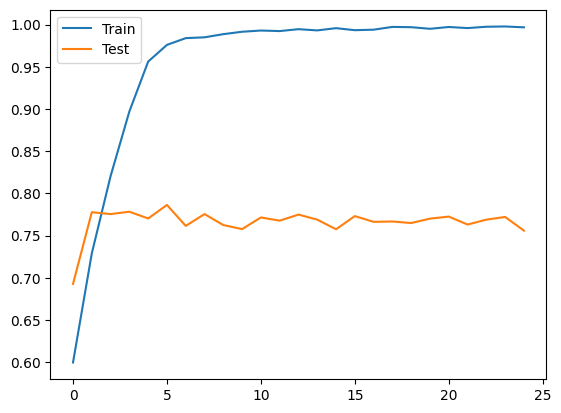

In [17]:
plt.plot(history.history["accuracy"], label = "Train")
plt.plot(history.history["val_accuracy"], label = "Test")
plt.legend()
plt.show()

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,541,893 (169.91 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 29,694,596 (113.28 MB)

In [19]:
from keras.layers import BatchNormalization, Dropout

In [20]:
model = Sequential()

In [21]:
model = Sequential()

model.add(Conv2D(32, kernel_size = (3, 3), padding = "valid", activation = "relu", input_shape = (256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2, 2), strides = 2, padding = "valid"))

model.add(Conv2D(64, kernel_size = (3, 3), padding = "valid", activation = "relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2, 2), strides = 2, padding = "valid"))

model.add(Conv2D(128, kernel_size = (3, 3), activation = "relu", padding = "valid"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2, 2), strides = 2, padding = "valid"))

model.add(Flatten())
model.add(Dense(128, activation = "relu"))
model.add(Dropout(0.2))
model.add(Dense(64, activation = "relu"))

model.add(Dense(1, activation = "sigmoid"))

In [22]:
model.compile(loss = "binary_crossentropy", optimizer = "adam", metrics = ["accuracy"])

In [23]:
history = model.fit(train_ds, epochs = 20, validation_data = test_ds)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.5647 - loss: 1.0978 - val_accuracy: 0.5802 - val_loss: 0.7039
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 90ms/step - accuracy: 0.6740 - loss: 0.5924 - val_accuracy: 0.7004 - val_loss: 0.6008
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 96ms/step - accuracy: 0.7408 - loss: 0.5220 - val_accuracy: 0.7358 - val_loss: 0.5108
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.7706 - loss: 0.4643 - val_accuracy: 0.7730 - val_loss: 0.4589
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.7801 - loss: 0.4477 - val_accuracy: 0.7488 - val_loss: 0.5201
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.8028 - loss: 0.3988 - val_accuracy: 0.7536 - val_loss: 0.4664
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 97ms/step - accuracy: 0.8216 - loss: 0.3631 - val_accuracy: 0.7132 - val_loss: 0.5509
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.8479 - loss: 0.3124 - 

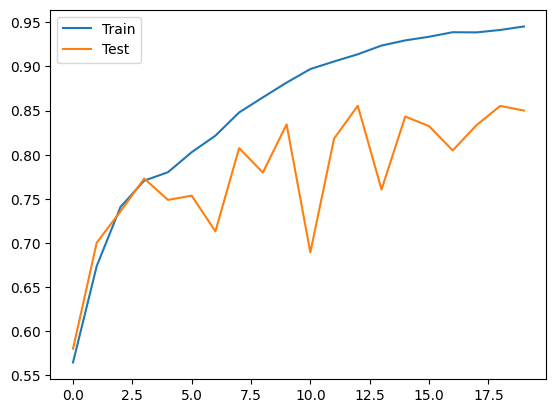

In [24]:
plt.plot(history.history["accuracy"], label = "Train")
plt.plot(history.history["val_accuracy"], label = "Test")
plt.legend()
plt.show()

In [25]:
error, accuracy = model.evaluate(test_ds)

157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.8500 - loss: 0.7553


In [26]:
import cv2

In [27]:
test_img = cv2.imread("/content/Dog1.jfif")

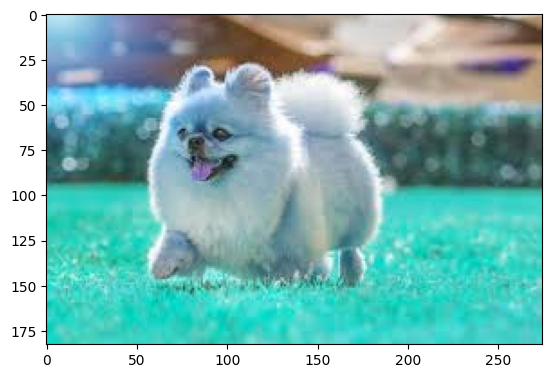

In [28]:
plt.imshow(test_img)

In [29]:
import numpy as np
img = keras.utils.load_img("/content/Dog1.jfif", target_size = (256, 256))
img_array = keras.utils.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis = 0)
pred = model.predict(img_array)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
[[0.9957371]]


In [30]:
if pred[0][0] > 0.5 :
  print("Dog")
else :
  print("Cat")

Dog
